# PHYS 449 - Homework 5, Question 2

**Student Name:** Allen Mathew \
**Student ID:** 20964892 \
**Due Date:** Thursday, October 9, 3:00pm 

*ChatGPT was used to help generate the code*
- - -


2. Produce a dataset $\mathcal{D}$ from a $28$ × $28$ Ising model. Each element of the dataset is a vector of spin configurations (drawn from the Boltzmann distribution at equilibrium at temperature $T$), and its respective classification of FM or PM. The dataset should consist of $i.i.d.$ sampled configurations for $30$ or $40$ $T$ values evenly distributed in the interval $[1.0, 3.5]$. Label each configuration vector sampled for $T < 2.269$ as $FM$, and those for $T > 2.269$ as $PM$. Build a data set with cardinality in the ballpark of $|\mathcal{D}| ≈ 10^6$, and divide your dataset into $80%$ training and $20%$ validation.

In [1]:
from dataclasses import dataclass, asdict
import numpy as np, os, math, json
from MonteCarlo import run_mcmc  # uses your existing script

Tc = 2.269  # critical temperature

@dataclass
class DataGenConfig:
    L: int = 28
    T_min: float = 1.0
    T_max: float = 3.5
    n_T: int = 40
    samples_per_T: int = 200   # increase later (~1000+) for big dataset
    burn_in_sweeps: int = 800
    thin_by: int = 20
    out_path: str = "ising_dataset_q2.npz"

def label_from_T(T): return 0 if T < Tc else 1

def generate_dataset(cfg):
    rng = np.random.default_rng(0)
    temps = np.linspace(cfg.T_min, cfg.T_max, cfg.n_T)
    X_list, y_list, T_list = [], [], []
    for T in temps:
        samples, _ = run_mcmc(cfg.L, cfg.samples_per_T, T)  # your MonteCarlo fn
        X_list.append(np.array(samples).reshape(cfg.samples_per_T, -1))
        y_list.append(np.full(cfg.samples_per_T, label_from_T(T), int))
        T_list.append(np.full(cfg.samples_per_T, T, float))
    X, y, T = map(np.concatenate, (X_list, y_list, T_list))
    np.savez(cfg.out_path, X=X, y=y, T=T, meta=asdict(cfg))
    print(f"Saved {cfg.out_path} — X:{X.shape}, y:{y.shape}")
    return X, y, T

cfg = DataGenConfig()
if os.path.exists(cfg.out_path):
    data = np.load(cfg.out_path, allow_pickle=True)
    X, y, T = data["X"], data["y"], data["T"]
else:
    X, y, T = generate_dataset(cfg)

# map spins {-1,+1} → {0,1}
Xf = (X.astype(np.float32) + 1.0) / 2.0
print(f"Xf: {Xf.shape}, y: {y.shape}, T: {T.shape}")

Saved ising_dataset_q2.npz — X:(8000, 784), y:(8000,)
Xf: (8000, 784), y: (8000,), T: (8000,)


In [5]:
def stratified_split(X, y, T, train_frac=0.8, seed=42):
    rng = np.random.default_rng(seed)
    bins = np.digitize(T, np.linspace(T.min(), T.max(), 21))
    groups = {}
    for i, key in enumerate(zip(y, bins)):
        groups.setdefault(key, []).append(i)
    train, val = [], []
    for inds in groups.values():
        inds = np.array(inds)
        rng.shuffle(inds)
        k = int(len(inds) * train_frac)
        train += inds[:k].tolist()
        val   += inds[k:].tolist()
    return np.array(train), np.array(val)

train_idx, val_idx = stratified_split(Xf, y, T)
X_train, y_train, T_train = Xf[train_idx], y[train_idx], T[train_idx]
X_val,   y_val,   T_val   = Xf[val_idx],  y[val_idx],  T[val_idx]

# Ensure correct dtypes for CE loss
X_train = X_train.astype(np.float32)
X_val   = X_val.astype(np.float32)
y_train = y_train.astype(np.int64)
y_val   = y_val.astype(np.int64)


In [6]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

class MLP(nn.Module):
    def __init__(self, in_dim=784, hidden=(256,128), p_drop=0.0):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            if p_drop: layers += [nn.Dropout(p_drop)]
            prev = h
        layers += [nn.Linear(prev, 2)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

@dataclass
class TrainCfg:
    lr: float = 1e-3; epochs: int = 10
    batch: int = 512; weight_decay: float = 0.0
    l1_lambda: float = 0.0; p_drop: float = 0.0
    hidden: tuple = (256,128)
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

def train_model(X_train, y_train, X_val, y_val, cfg: TrainCfg):
    dev = cfg.device
    # enforce dtypes for CE loss
    Xtr = torch.as_tensor(X_train, dtype=torch.float32, device=dev)
    ytr = torch.as_tensor(y_train, dtype=torch.long,     device=dev)
    Xva = torch.as_tensor(X_val,   dtype=torch.float32, device=dev)
    yva = torch.as_tensor(y_val,   dtype=torch.long,     device=dev)

    train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=cfg.batch, shuffle=True)
    val_loader   = DataLoader(TensorDataset(Xva, yva), batch_size=cfg.batch)

    model = MLP(Xtr.shape[1], cfg.hidden, cfg.p_drop).to(dev)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    loss_fn = nn.CrossEntropyLoss()

    hist = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
    for ep in range(cfg.epochs):
        model.train(); tl, ta, n = 0.0, 0, 0
        for xb, yb in train_loader:
            opt.zero_grad(set_to_none=True)
            out = model(xb)
            loss = loss_fn(out, yb)
            if cfg.l1_lambda:
                loss = loss + cfg.l1_lambda * sum(p.abs().sum() for p in model.parameters())
            loss.backward(); opt.step()
            tl += loss.item() * yb.size(0)
            ta += (out.argmax(1) == yb).sum().item()
            n  += yb.size(0)
        hist["train_loss"].append(tl/n); hist["train_acc"].append(ta/n)

        model.eval(); vl, va, n = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                out = model(xb)
                vl += loss_fn(out, yb).item() * yb.size(0)
                va += (out.argmax(1) == yb).sum().item()
                n  += yb.size(0)
        hist["val_loss"].append(vl/n); hist["val_acc"].append(va/n)
        print(f"Epoch {ep+1}: train_acc={hist['train_acc'][-1]:.3f}  val_acc={hist['val_acc'][-1]:.3f}")
    return model, hist


def plot_loss(hist,name):
    plt.plot(hist["train_loss"],label="train")
    plt.plot(hist["val_loss"],label="val")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.tight_layout()
    plt.savefig(name,dpi=150); plt.close()


(a) Train a feed forward neural network to classify the configurations. Use the cost functions, activations, optimizer, and hyperparameters that you had the most success with in Homework 3. Plot the training loss as a function of epoch.

In [7]:
base = TrainCfg()
model_a, hist_a = train_model(X_train, y_train, X_val, y_val, base)
plot_loss(hist_a, "part_a_loss.png")

Epoch 1: train_acc=0.718  val_acc=0.828
Epoch 2: train_acc=0.848  val_acc=0.852
Epoch 3: train_acc=0.907  val_acc=0.923
Epoch 4: train_acc=0.963  val_acc=0.968
Epoch 5: train_acc=0.988  val_acc=0.984
Epoch 6: train_acc=0.996  val_acc=0.989
Epoch 7: train_acc=0.999  val_acc=0.994
Epoch 8: train_acc=1.000  val_acc=0.993
Epoch 9: train_acc=1.000  val_acc=0.995
Epoch 10: train_acc=1.000  val_acc=0.996


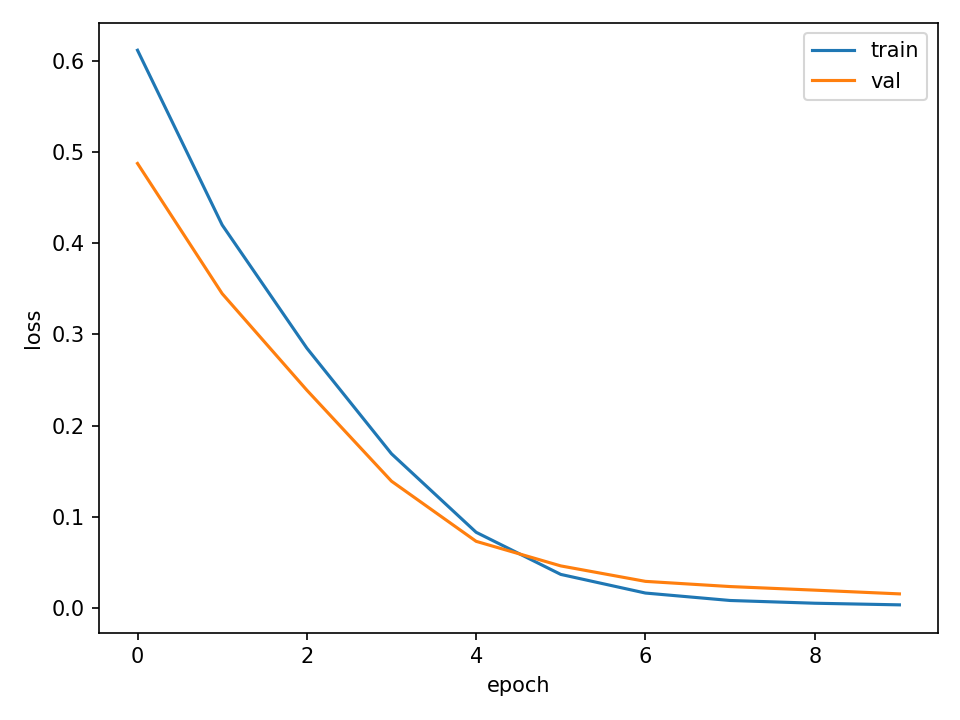

(b) Explore $L1$, $L2$, and dropout, and choose the best regularization method for your dataset. Present data to justify your choice.

In [8]:
cfgs = [
    ("baseline", base),
    ("l2_1e-4", TrainCfg(**{**asdict(base),"weight_decay":1e-4})),
    ("l1_1e-6", TrainCfg(**{**asdict(base),"l1_lambda":1e-6})),
    ("drop_0.3", TrainCfg(**{**asdict(base),"p_drop":0.3})),
]
best_name, best_acc, best_m, best_cfg = None, 0, None, None
results = {}

for name,cfg in cfgs:
    m,h = train_model(X_train,y_train,X_val,y_val,cfg)
    acc = h["val_acc"][-1]
    results[name] = acc
    if acc>best_acc: best_acc, best_name, best_m, best_cfg = acc,name,m,cfg

print("Best:",best_name,best_acc)
with open("part_b_results.json","w") as f: json.dump(results,f,indent=2)

Epoch 1: train_acc=0.689  val_acc=0.817
Epoch 2: train_acc=0.832  val_acc=0.842
Epoch 3: train_acc=0.895  val_acc=0.931
Epoch 4: train_acc=0.953  val_acc=0.942
Epoch 5: train_acc=0.982  val_acc=0.986
Epoch 6: train_acc=0.995  val_acc=0.990
Epoch 7: train_acc=0.999  val_acc=0.991
Epoch 8: train_acc=1.000  val_acc=0.994
Epoch 9: train_acc=1.000  val_acc=0.994
Epoch 10: train_acc=1.000  val_acc=0.996
Epoch 1: train_acc=0.670  val_acc=0.792
Epoch 2: train_acc=0.845  val_acc=0.850
Epoch 3: train_acc=0.889  val_acc=0.872
Epoch 4: train_acc=0.953  val_acc=0.966
Epoch 5: train_acc=0.987  val_acc=0.984
Epoch 6: train_acc=0.996  val_acc=0.992
Epoch 7: train_acc=0.998  val_acc=0.979
Epoch 8: train_acc=0.971  val_acc=0.987
Epoch 9: train_acc=0.999  val_acc=0.993
Epoch 10: train_acc=1.000  val_acc=0.995
Epoch 1: train_acc=0.709  val_acc=0.755
Epoch 2: train_acc=0.826  val_acc=0.853
Epoch 3: train_acc=0.891  val_acc=0.927
Epoch 4: train_acc=0.950  val_acc=0.944
Epoch 5: train_acc=0.975  val_acc=0.97

(c) Once you have chosen your best architechture, produce plots of the neuron output (i.e. the probability of a $FM$ and $PM$ classification) and the classification accuracy, as a function of temperature $T$. Discuss your results in the context of the known physics of the Ising model.

In [9]:
def temperature_curves(model,X,y,T,device):
    model.eval()
    with torch.no_grad():
        out = model(torch.tensor(X,device=device))
        probs = torch.softmax(out,1).cpu().numpy()
        preds = probs.argmax(1)
    uniq = np.unique(T)
    acc, pfm, ppm = [],[],[]
    for t in uniq:
        m = T==t
        acc.append((preds[m]==y[m]).mean())
        pfm.append(probs[m,0].mean()); ppm.append(probs[m,1].mean())
    return uniq, acc, pfm, ppm

Ts,acc,pfm,ppm = temperature_curves(best_m,X_val,y_val,T_val,best_cfg.device)

plt.plot(Ts,acc,"o-"); plt.axvline(Tc,ls="--"); plt.xlabel("T"); plt.ylabel("accuracy")
plt.tight_layout(); plt.savefig("part_c_accuracy_vs_T.png",dpi=150); plt.close()

plt.plot(Ts,pfm,"o-",label="P(FM)")
plt.plot(Ts,ppm,"x-",label="P(PM)")
plt.axvline(Tc,ls="--"); plt.legend(); plt.xlabel("T")
plt.tight_layout(); plt.savefig("part_c_probs_vs_T.png",dpi=150); plt.close()

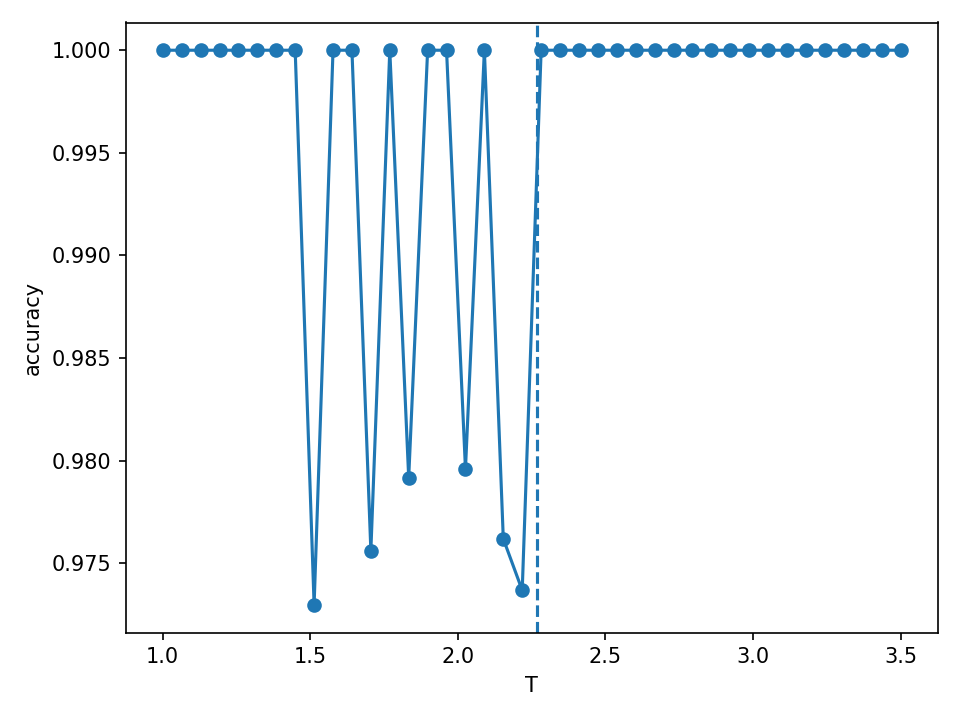

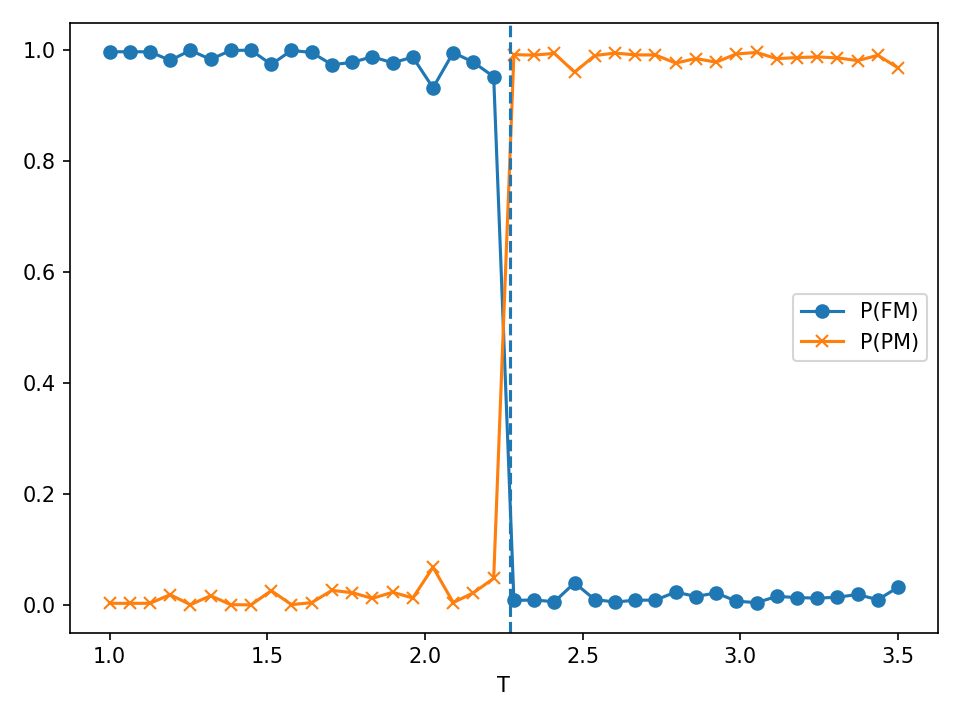

(d) Explore the performance of your network with additional hidden layers. Can you improve the classification accuracy, while using a smaller number of total parameters, in a deep architechture?

In [10]:
archs = [
    ("shallow_256", (256,)),
    ("two_128", (128,128)),
    ("three_96", (96,96,96)),
    ("deep_small", (64,64,64,64)),
]

results_d = {}
for name,hid in archs:
    cfg = TrainCfg(**{**asdict(best_cfg),"hidden":hid})
    m,h = train_model(X_train,y_train,X_val,y_val,cfg)
    results_d[name] = {
        "params": count_params(m),
        "train_acc": h["train_acc"][-1],
        "val_acc": h["val_acc"][-1],
    }

with open("part_d_results.json","w") as f: json.dump(results_d,f,indent=2)
results_d

Epoch 1: train_acc=0.613  val_acc=0.673
Epoch 2: train_acc=0.772  val_acc=0.845
Epoch 3: train_acc=0.840  val_acc=0.825
Epoch 4: train_acc=0.849  val_acc=0.842
Epoch 5: train_acc=0.858  val_acc=0.859
Epoch 6: train_acc=0.877  val_acc=0.896
Epoch 7: train_acc=0.916  val_acc=0.914
Epoch 8: train_acc=0.935  val_acc=0.883
Epoch 9: train_acc=0.949  val_acc=0.953
Epoch 10: train_acc=0.977  val_acc=0.966
Epoch 1: train_acc=0.679  val_acc=0.788
Epoch 2: train_acc=0.820  val_acc=0.829
Epoch 3: train_acc=0.874  val_acc=0.913
Epoch 4: train_acc=0.923  val_acc=0.942
Epoch 5: train_acc=0.968  val_acc=0.959
Epoch 6: train_acc=0.984  val_acc=0.978
Epoch 7: train_acc=0.994  val_acc=0.982
Epoch 8: train_acc=0.995  val_acc=0.981
Epoch 9: train_acc=0.998  val_acc=0.989
Epoch 10: train_acc=1.000  val_acc=0.996
Epoch 1: train_acc=0.716  val_acc=0.794
Epoch 2: train_acc=0.813  val_acc=0.832
Epoch 3: train_acc=0.876  val_acc=0.903
Epoch 4: train_acc=0.924  val_acc=0.948
Epoch 5: train_acc=0.976  val_acc=0.97

{'shallow_256': {'params': 201474,
  'train_acc': 0.97734375,
  'val_acc': 0.965625},
 'two_128': {'params': 117250, 'train_acc': 0.99953125, 'val_acc': 0.99625},
 'three_96': {'params': 94178, 'train_acc': 1.0, 'val_acc': 0.99125},
 'deep_small': {'params': 62850, 'train_acc': 0.9921875, 'val_acc': 0.985625}}